In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt

from src.data.market_loader import MarketLoader

from src.curves.curve_snapshot import CurveSnapshot
from src.curves.bootstrap.bootstrap_engine import BootstrapCurveEngine
from src.curves.projection_curve import ProjectionCurve
from src.curves.zero_curve import ZeroCurve

from src.instruments.instrument_builder import InstrumentBuilder

from src.trades.interest_rate_swap import InterestRateSwap

from src.pricing.swap_pricer import SwapPricer

from src.curves.simulator.hull_white import HullWhiteSimulator

from src.risk.exposure.stochastic_exposure_engine import MonteCarloExposureEngine

In [2]:
# downloading market curves
market_loader = MarketLoader()
market_curves = market_loader.market_loader_pipeline()

# downloading swap curves
swap_loader = MarketLoader()
swap_curves = swap_loader.swap_loader_pipeline()

treasury curve dataset already downloaded..
sofr curve dataset already downloaded..
futures curve dataset already downloaded..
estr curve dataset already downloaded..
usd_ois curve dataset already downloaded..
eur_ois curve dataset already downloaded..


In [3]:
### create curve snapshots
# SOFR snapshot
sofr_df = market_curves['sofr']

latest_date = sofr_df.index[-1]
latest_sofr_curve = sofr_df.iloc[-1]

sofr_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'sofr',
    as_of_date = latest_date,
    curve_row = latest_sofr_curve
)

# Futures snapshot
future_df = market_curves['futures']
latest_futures_curve = future_df.iloc[-1]

futures_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'futures',
    as_of_date = latest_date,
    curve_row = latest_futures_curve
)

# OIS snapshot
ois_df = swap_curves['usd_ois']

latest_swap_date = ois_df.index[-1]
latest_swap_curve = ois_df.iloc[-1]

ois_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'usd_ois',
    as_of_date = latest_swap_date,
    curve_row = latest_swap_curve
)

In [4]:
### create instruments from curve snapshot
# deposits
deposit_instruments = InstrumentBuilder.build_deposit_instruments(snapshot = sofr_snapshot)

# futures
future_instruments = InstrumentBuilder.build_future_instruments(snapshot = futures_snapshot)

# ois
ois_instruments = InstrumentBuilder.build_ois_instruments(snapshot = ois_snapshot)

### discount, projection and zero curve builder
# bootstrapping engine for generating the discount curve
all_instruments = deposit_instruments + future_instruments + ois_instruments

engine = BootstrapCurveEngine()

discount_curve = engine.bootstrap(
    snapshot = sofr_snapshot,
    instruments = all_instruments
)

# projection curve
projection_curve = ProjectionCurve(discount_curve = discount_curve)

# zero curve
zero_curve = ZeroCurve(discount_curve = discount_curve)

In [5]:
# sample IRS trade objects
IR_swap = InterestRateSwap(
    notional = 1_000_000,
    maturity = 3.0,
    fixed_rate = 3.40,
    pay_fixed = True
)

In [6]:
### exposure risk analytics
# pricer
pricer = SwapPricer(
    discount_curve = discount_curve,
    projection_curve = projection_curve
)

pv = pricer.price(swap = IR_swap)
print(f'PV = {pv:.2f}')

# simulator
simulator = HullWhiteSimulator(
    r0 = min(zero_curve.zero_rates.values()),
    random_seed = 12,
    mean_reversion = 0.1,
    volatility = 0.002
)

# exposure engine
mc_engine = MonteCarloExposureEngine(
    pricer = pricer,
    simulator = simulator,
    zero_curve = zero_curve
)

PV = 7858.41


In [7]:
# expected exposure
ee = mc_engine.expected_exposure(
    swap = IR_swap, 
    n_paths = 250
)
ee

,Times,EE
0,0.00,7858.414276
1,0.25,7490.225219
2,0.50,7098.089779
3,0.75,5718.773644
4,1.00,4558.018079
5,1.25,4082.127955
6,1.50,3335.136975
7,1.75,2489.983124
8,2.00,1652.971341
9,2.25,1298.426304


In [8]:
# expected negative exposure
ene = mc_engine.expected_negative_exposure(
    swap = IR_swap,
    n_paths = 250
)
ene

,Times,ENE
0,0.00,-0.000000
1,0.25,-0.000000
2,0.50,24.376613
3,0.75,84.633602
4,1.00,179.598257
5,1.25,201.544829
6,1.50,289.259128
7,1.75,331.594707
8,2.00,488.628035
9,2.25,395.334351


In [9]:
# potential future exposure
perc = 95.0

pfe = mc_engine.potential_future_exposure(
    swap = IR_swap,
    percentile = perc,
    n_paths = 250
)
pfe

,Times,PFE_95%
0,0.00,7858.414276
1,0.25,12081.369902
2,0.50,12752.302783
3,0.75,11657.023748
4,1.00,10158.590336
5,1.25,9277.345274
6,1.50,8024.143414
7,1.75,6673.782322
8,2.00,5284.520204
9,2.25,4197.755848


In [10]:
# expected positive exposure
epe = mc_engine.expected_positive_exposure(
    swap = IR_swap,
    n_paths = 250
)
epe

3626.2635260633897

In [11]:
mc_engine.mc_exposure_report(swap = IR_swap, n_paths = 250)

,Times,EE,ENE,PFE_95%,EffectiveEE
0,0.00,7858.414276,-0.000000,7858.414276,7858.414276
1,0.25,7401.343505,2.018885,11435.328749,7858.414276
2,0.50,6837.137263,40.565952,12523.915102,7858.414276
3,0.75,5521.614705,112.948626,11194.612663,7858.414276
4,1.00,4507.488239,222.107639,9771.652320,7858.414276
5,1.25,3812.450734,326.496940,10169.588660,7858.414276
6,1.50,3363.161651,365.054046,9029.892003,7858.414276
7,1.75,2574.162615,447.081143,7212.840429,7858.414276
8,2.00,1731.177027,547.809750,5685.721468,7858.414276
9,2.25,1412.947158,421.360217,4616.195946,7858.414276


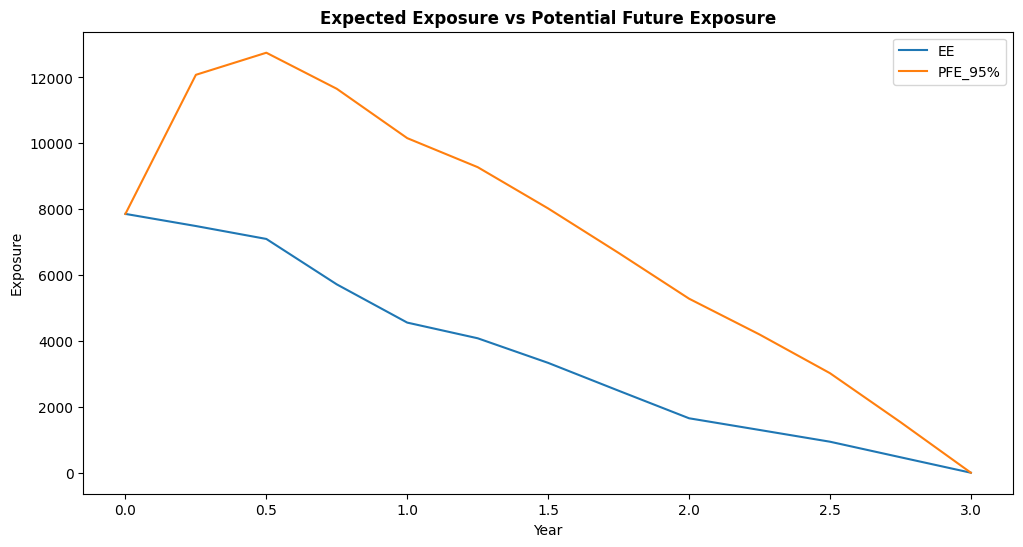

In [12]:
# plot expected exposure vs potential future exposue
plt.figure(figsize = (12, 6))

plt.plot(ee['Times'], ee['EE'], label = 'EE')
plt.plot(pfe['Times'], pfe[f'PFE_{perc:.0f}%'], label = f'PFE_{perc:.0f}%')

plt.title('Expected Exposure vs Potential Future Exposure', fontweight = 'bold')
plt.xlabel('Year')
plt.ylabel('Exposure')
plt.legend(loc = 'best')
plt.show()

In [13]:
# effective expected exposure & effective EPE
effective_ee = mc_engine.effective_expected_exposure(
    swap = IR_swap,
    n_paths = 250,
    steps_per_year = 4
)

effective_epe = mc_engine.effected_expected_positive_exposure(
    swap = IR_swap,
    n_paths = 250,
    steps_per_year = 4
)

print(f'Effective EPE: {effective_epe:.1f}')

display(effective_ee)

Effective EPE: 7858.4


,Times,EffectiveEE
0,0.00,7858.414276
1,0.25,7858.414276
2,0.50,7858.414276
3,0.75,7858.414276
4,1.00,7858.414276
5,1.25,7858.414276
6,1.50,7858.414276
7,1.75,7858.414276
8,2.00,7858.414276
9,2.25,7858.414276


In [ ]:
# full exposure report
mc_engine.full_exposure_report(
    swap = IR_swap,
    percentile = 95,
    n_paths = 250,
    steps_per_year = 4
)

,Metric,Value
0,Current Exposure,7858.414276
1,Peak EE,7858.414276
2,Peak ENE,571.185406
3,Peak PFE,11347.839879
4,EPE,3549.198352
5,Effective EPE,7858.414276
